# Data Exploration

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# For imbalanced handling
from imblearn.pipeline import Pipeline as ImbPipeline   # to allow SMOTE inside CV safely
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

In [2]:
train = pd.read_csv("mnt/data/dataset-train-vf.csv")
test  = pd.read_csv("mnt/data/dataset-test-vf.csv")

In [3]:
print("Train shape:", train.shape)
print("Test shape:",  test.shape)

print("\nTrain head():")
display(train.head())

print("\nTest head():")
display(test.head())

Train shape: (4480, 13)
Test shape: (792, 12)

Train head():


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,y
0,1,NaN,62330,NaN,0.748,4.845455,30405,18.066667,2.807634,663180,NaN,C1,square
1,2,NaN,4370,NaN,0.858,1.072727,2445,1.266667,0.712986,49420,NaN,C2,square
2,3,0.000729,1449,196.3,0.841,0.172727,795,0.420000,0.112528,16240,NaN,C2,square
3,4,0.043499,24702,349.7,0.594,5.254545,9570,7.160000,2.417831,239680,0.430355,C3,circle
4,5,0.000972,1104,162.5,0.792,0.109091,570,0.320000,0.066930,12040,NaN,C3,square



Test head():


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
0,4481,NaN,8855,NaN,0.657,1.336364,3795,2.566667,0.680134,89320,NaN,C2
1,4482,0.014257,40480,117.65,0.552,2.900000,14580,11.733333,1.240056,382480,NaN,C1
2,4483,0.000567,966,340.60,1.000,0.200000,630,0.280000,0.154930,11760,0.021441,C3
3,4484,NaN,1035,NaN,0.911,0.218182,615,0.300000,0.153972,12040,NaN,C1
4,4485,0.000972,2208,297.70,0.865,0.400000,1245,0.640000,0.268028,25060,0.027402,C4


In [4]:
print("Train columns:\n", train.columns.tolist())
print("\nTest columns:\n", test.columns.tolist())

print("\nTrain dtypes:")
print(train.dtypes)

print("\nTrain info():")
train.info()

Train columns:
 ['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'y']

Test columns:
 ['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

Train dtypes:
ID       int64
f1     float64
f2       int64
f3     float64
f4     float64
f5     float64
f6       int64
f7     float64
f8     float64
f9       int64
f10    float64
f11     object
y       object
dtype: object

Train info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4480 entries, 0 to 4479
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      4480 non-null   int64  
 1   f1      2642 non-null   float64
 2   f2      4480 non-null   int64  
 3   f3      3096 non-null   float64
 4   f4      4480 non-null   float64
 5   f5      4480 non-null   float64
 6   f6      4480 non-null   int64  
 7   f7      4480 non-null   float64
 8   f8      4480 non-null   float64
 9   f9      4480 non-null   int64  
 10  f10     568 non-nu

In [5]:
# Count of missing values
train_na_count = train.isna().sum()
test_na_count  = test.isna().sum()

print("Missing values in TRAIN:\n", train_na_count)
print("\nMissing values in TEST:\n", test_na_count)

# Percentage of missing values
train_na_pct = train.isna().mean() * 100
test_na_pct  = test.isna().mean() * 100

print("\nMissing % in TRAIN:\n", train_na_pct.round(2))
print("\nMissing % in TEST:\n", test_na_pct.round(2))


Missing values in TRAIN:
 ID        0
f1     1838
f2        0
f3     1384
f4        0
f5        0
f6        0
f7        0
f8        0
f9        0
f10    3912
f11       0
y         0
dtype: int64

Missing values in TEST:
 ID       0
f1     306
f2       0
f3     243
f4       0
f5       0
f6       0
f7       0
f8       0
f9       0
f10    668
f11      0
dtype: int64

Missing % in TRAIN:
 ID      0.00
f1     41.03
f2      0.00
f3     30.89
f4      0.00
f5      0.00
f6      0.00
f7      0.00
f8      0.00
f9      0.00
f10    87.32
f11     0.00
y       0.00
dtype: float64

Missing % in TEST:
 ID      0.00
f1     38.64
f2      0.00
f3     30.68
f4      0.00
f5      0.00
f6      0.00
f7      0.00
f8      0.00
f9      0.00
f10    84.34
f11     0.00
dtype: float64


##### Column "F10" is insanely under represented. We may consider dropping it if imputing doesn't work
##### for now we will deal with missing values with normal imputaion. mean and mode and the usual
##### let us check imbalance first

In [6]:
# Target distribution in train
print("Target value counts:")
print(train["y"].value_counts())
print("\nTarget %:")
print((train["y"].value_counts(normalize=True) * 100).round(2))

# Categorical feature f11
print("\nUnique values in f11:")
print(train["f11"].value_counts())


Target value counts:
y
square    4181
circle     299
Name: count, dtype: int64

Target %:
y
square    93.33
circle     6.67
Name: proportion, dtype: float64

Unique values in f11:
f11
C3    1152
C2    1133
C1    1110
C4    1085
Name: count, dtype: int64


I can see that data is greatly imbalanced, my first idea is to use SMOTE to fix that, we'll see how that work
moreover, F11 is well balanced, simple one hot encoding should work. at leat for now

In [7]:
num_cols = train.select_dtypes(include=["number"]).columns.tolist()
print("Numeric columns:", num_cols)

print("\nDescriptive stats for numeric columns (TRAIN):")
display(train[num_cols].describe().T)


Numeric columns: ['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10']

Descriptive stats for numeric columns (TRAIN):


,count,mean,std,min,25%,50%,75%,max
ID,4480.0,2240.500000,1293.408932,1.000000,1120.750000,2240.500000,3360.250000,4.480000e+03
f1,2642.0,0.007127,0.009138,0.000081,0.001397,0.003321,0.008586,4.471446e-02
f2,4480.0,25597.162054,94005.638440,161.000000,2783.000000,7590.000000,22701.000000,3.311839e+06
f3,3096.0,234.375598,106.207714,35.750000,170.300000,218.075000,271.050000,6.500000e+02
f4,4480.0,0.786005,0.163220,0.062000,0.681000,0.802500,0.920000,1.000000e+00
f5,4480.0,3.162125,10.189312,0.009091,0.400000,1.004545,2.581818,2.553909e+02
f6,4480.0,10897.995536,25574.563533,105.000000,1530.000000,3885.000000,11070.000000,6.423150e+05
f7,4480.0,7.419467,27.248011,0.046667,0.806667,2.200000,6.580000,9.599533e+02
f8,4480.0,1.804952,5.978266,0.006204,0.252502,0.600454,1.471806,1.606886e+02
f9,4480.0,257523.437500,773903.649296,1960.000000,31360.000000,84000.000000,241920.000000,2.339190e+07


Seems like the data has some outliers -  for example in f9 ( the mean is in hundreds of thousnads, but max is in 23 million)

morever, i see heavy tails especially in f2, f6, f7, f8, f9 where max is way above the 75% quantile. 

let us try to visualize that

In [8]:
import matplotlib.pyplot as plt

# Identify numeric columns (excluding ID and y)
num_cols = [c for c in train.columns 
            if (train[c].dtype != "O") and (c not in ["ID", "y"])]

print("Numeric columns:", num_cols)

Numeric columns: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10']


In [9]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        out_low  = (s < lower).sum()
        out_high = (s > upper).sum()
        n = s.shape[0]
        rows.append({
            "col": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "out_low": out_low,
            "out_high": out_high,
            "out_total": out_low + out_high,
            "n_nonnull": n,
            "out_%": (out_low + out_high) * 100.0 / n
        })
    return pd.DataFrame(rows)

outlier_stats = iqr_outlier_summary(train, num_cols)
display(outlier_stats)


,col,q1,q3,iqr,lower_bound,upper_bound,out_low,out_high,out_total,n_nonnull,out_%
0,f1,0.001397,0.008586,0.007189,-0.009386,0.019370,0,289,289,2642,10.938683
1,f2,2783.000000,22701.000000,19918.000000,-27094.000000,52578.000000,0,554,554,4480,12.366071
2,f3,170.300000,271.050000,100.750000,19.175000,422.175000,0,169,169,3096,5.458656
3,f4,0.681000,0.920000,0.239000,0.322500,1.278500,48,0,48,4480,1.071429
4,f5,0.400000,2.581818,2.181818,-2.872727,5.854545,0,471,471,4480,10.513393
5,f6,1530.000000,11070.000000,9540.000000,-12780.000000,25380.000000,0,470,470,4480,10.491071
6,f7,0.806667,6.580000,5.773333,-7.853333,15.240000,0,554,554,4480,12.366071
7,f8,0.252502,1.471806,1.219305,-1.576455,3.300763,0,449,449,4480,10.022321
8,f9,31360.000000,241920.000000,210560.000000,-284480.000000,557760.000000,0,520,520,4480,11.607143
9,f10,0.251716,0.759281,0.507565,-0.509632,1.520629,0,0,0,568,0.000000


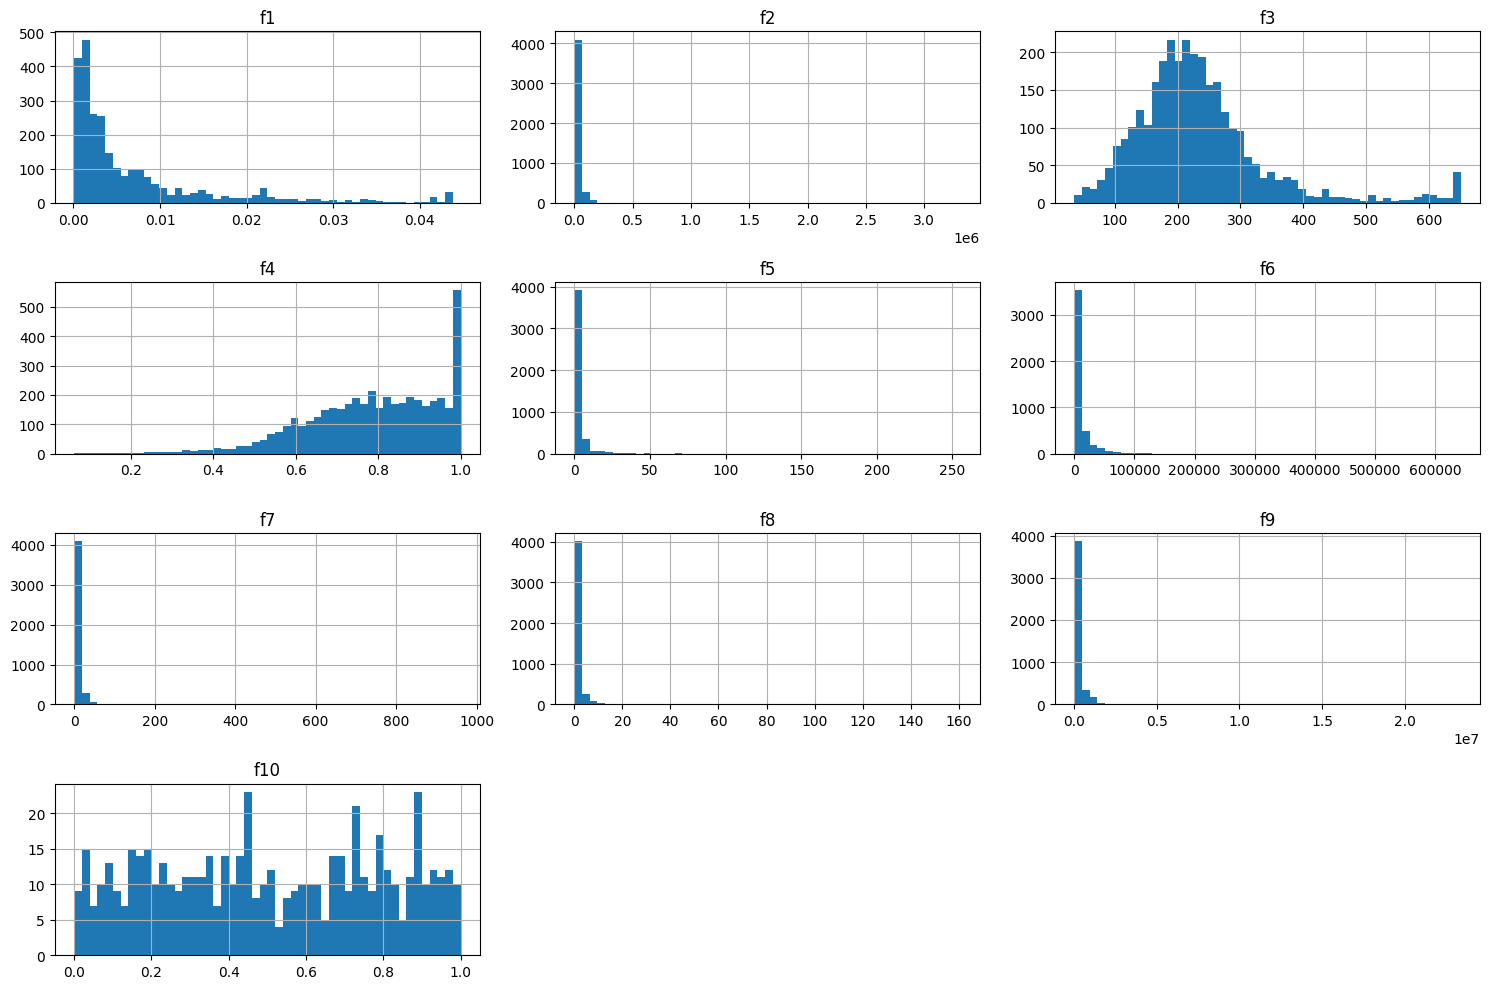

In [10]:
# Basic histograms for all numeric features
train[num_cols].hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()


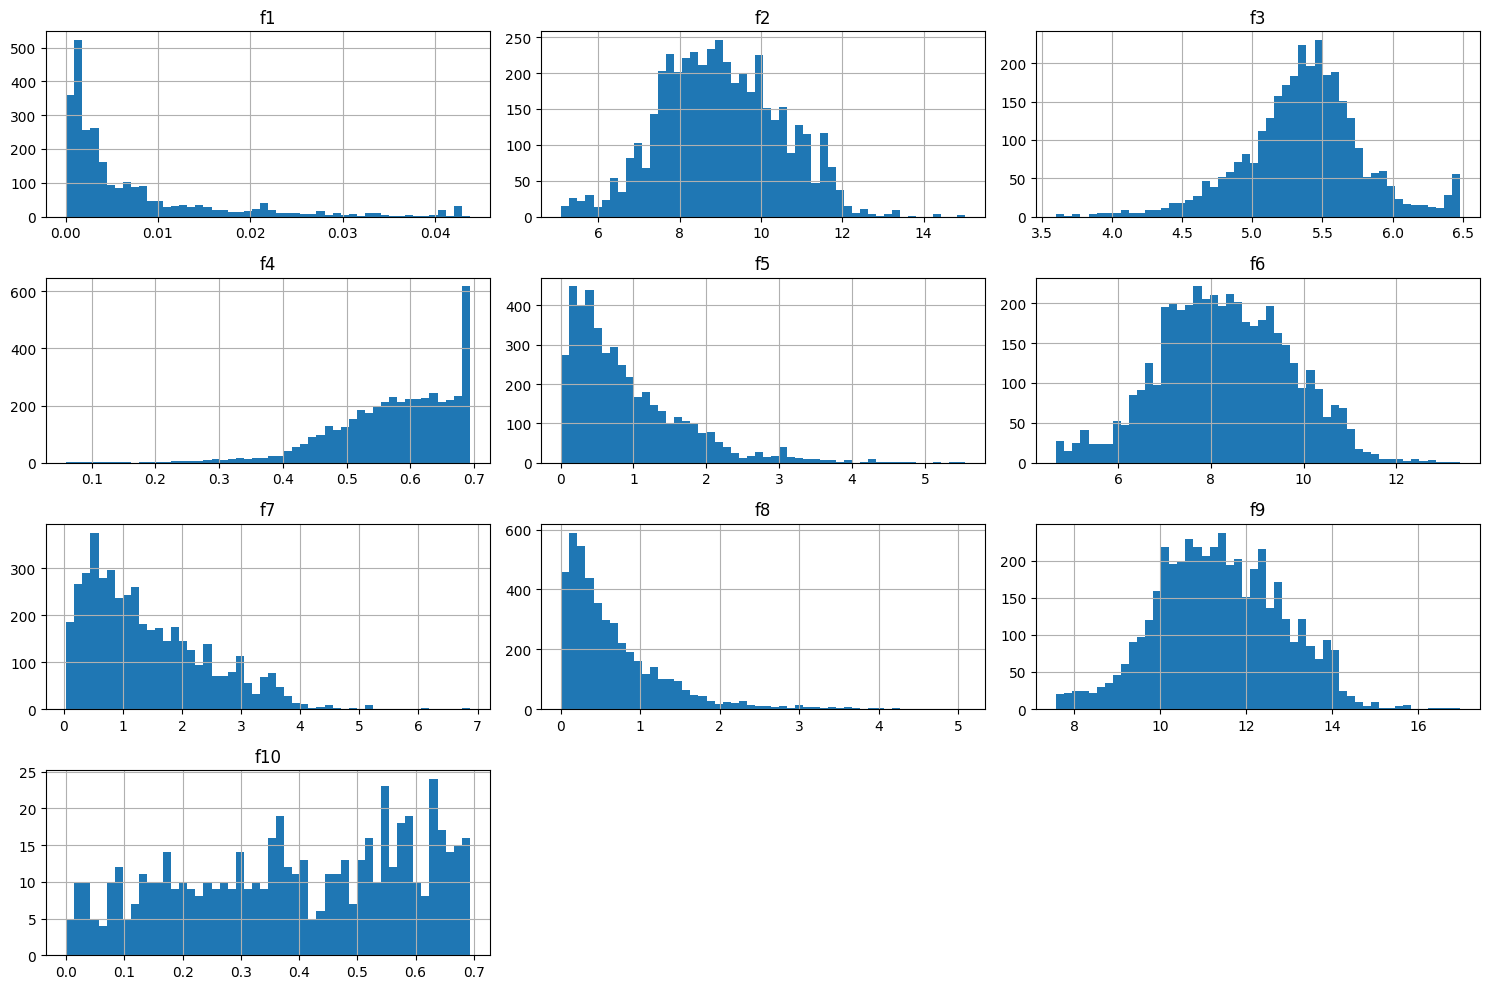

In [11]:
# Copy to avoid touching original
train_log = train[num_cols].copy()

# Add a small constant for strictly positive features to avoid log(0)
for col in num_cols:
    # only log-transform if all non-missing values are >= 0
    s = train_log[col].dropna()
    if (s >= 0).all():
        train_log[col] = np.log1p(train_log[col])  # log(1 + x)

train_log.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()


### For now, we will fix the follwing

1. missing values
2. outliers
3. skewness for KNN

In [12]:
ID_COL = "ID"
TARGET = "y"

X_train = train.drop(columns=[ID_COL, TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[ID_COL])

# identify numeric and categorical features
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "O"]   # f11
num_cols = [c for c in X_train.columns if c not in cat_cols]
print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10']
Categorical: ['f11']


In [13]:
# numeric: median imputation (robust to outliers)
num_imputer = SimpleImputer(strategy="median")

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

# categorical: most frequent
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

# sanity check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:",  X_test.isna().sum().sum())


Remaining NaNs in train: 0
Remaining NaNs in test: 0


## For now, I just wanna see how the KNN is performing as a base model

In [14]:
# Getting X and Y

X = train.drop(columns=[ID_COL, TARGET])
y = train[TARGET]
X_test = test.drop(columns=[ID_COL])

In [15]:
# ---------- Column types ----------
cat_cols = [c for c in X.columns if X[c].dtype == "O"]   
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

Numeric cols: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10']
Categorical cols: ['f11']


In [16]:
# ---------- Preprocessing blocks ----------
# OneHotEncoder arg differs by sklearn version, make it robust:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# For KNN: impute + scale numeric
num_block_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # handles NaNs (f1,f3,f10)
    ("scaler",  StandardScaler())
])

# For tree models: impute only numeric
num_block_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical for both: impute + one-hot
cat_block = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  ohe)
])

# ColumnTransformer for KNN
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", num_block_scaled, num_cols),
        ("cat", cat_block,        cat_cols)
    ],
    remainder="drop"
)

# ColumnTransformer for tree models
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_block_tree, num_cols),
        ("cat", cat_block,      cat_cols)
    ],
    remainder="drop"
)

In [17]:
# ---------- Metric: F1 of minority class ----------
minority_label = y.value_counts().idxmin()   # should be 'circle'
print("Minority class:", minority_label)

f1_minority = make_scorer(f1_score, pos_label=minority_label)

Minority class: circle


In [18]:
# ---------- Stratified CV ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Feature Engineering

In [19]:
import pandas as pd

# Load (or reuse your existing train/test if already loaded)
train = pd.read_csv("mnt/data/dataset-train-vf.csv")
test  = pd.read_csv("mnt/data/dataset-test-vf.csv")

ID_COL = "ID"
TARGET = "y"

# --- Create indicator: 1 if f10 is missing, else 0 ---
train["f10_missing"] = train["f10"].isna().astype(int)
test["f10_missing"]  = test["f10"].isna().astype(int)

# --- Drop the original f10 column ---
train = train.drop(columns=["f10"])
test  = test.drop(columns=["f10"])

print(train[["f10_missing"]].head())
print(test[["f10_missing"]].head())


   f10_missing
0            1
1            1
2            1
3            0
4            1
   f10_missing
0            1
1            1
2            0
3            1
4            0


In [20]:
X = train.drop(columns=[ID_COL, TARGET])
y = train[TARGET]
X_test = test.drop(columns=[ID_COL])

# Categorical columns (still just f11)
cat_cols = [c for c in X.columns if X[c].dtype == "O"]   # ['f11']

# Numeric columns = all others, INCLUDING f10_missing now
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10_missing']
Categorical cols: ['f11']


# KNN & Random Forest

In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- OneHotEncoder (version-safe) ---
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numeric block for KNN: impute + scale
num_block_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Numeric block for trees: impute only
num_block_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical block: impute + one-hot
cat_block = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  ohe)
])

# ColumnTransformer for KNN
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", num_block_scaled, num_cols),
        ("cat", cat_block,        cat_cols)
    ],
    remainder="drop"
)

# ColumnTransformer for tree models
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_block_tree, num_cols),
        ("cat", cat_block,      cat_cols)
    ],
    remainder="drop"
)

# Metric: F1 for minority class
minority_label = y.value_counts().idxmin()
f1_minority = make_scorer(f1_score, pos_label=minority_label)

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Minority class:", minority_label)


Minority class: circle


In [22]:
# ---------- Balanced Random Forest pipeline ----------
brf_pipe = Pipeline(steps=[
    ("prep", preprocess_tree),    # impute + one-hot, no scaling
    ("clf", BalancedRandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
brf_grid = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 8, 12, 16],
    "clf__max_features": ["sqrt", "log2"],
    "clf__min_samples_leaf": [1, 2, 4]
}

brf_search = GridSearchCV(
    estimator=brf_pipe,
    param_grid=brf_grid,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

brf_search.fit(X, y)

print("Balanced RF best params:", brf_search.best_params_)
print("Balanced RF CV F1 (minority):", brf_search.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Balanced RF best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 800}
Balanced RF CV F1 (minority): 0.5305901500065241


In [23]:
# ---------- KNN + SMOTE pipeline ----------
knn_pipe = ImbPipeline(steps=[
    ("prep",  preprocess_scaled),
    ("smote", SMOTE(random_state=42)),
    ("clf",   KNeighborsClassifier())
])

knn_grid = {
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "clf__n_neighbors": [3, 5, 7, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_grid,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

knn_search.fit(X, y)

print("KNN best params:", knn_search.best_params_)
print("KNN CV F1 (minority):", knn_search.best_score_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
KNN best params: {'clf__n_neighbors': 5, 'clf__p': 2, 'clf__weights': 'uniform', 'smote__sampling_strategy': 0.2}
KNN CV F1 (minority): 0.5834997918903699


# Trying XGBoost instead of Random Forest

In [24]:


from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, make_scorer

# y is currently strings: 'square' / 'circle'
le_y = LabelEncoder()
y_xgb = le_y.fit_transform(y)   # encode to 0/1

# Find which encoded value corresponds to the minority class
minority_label_str = y.value_counts().idxmin()           # e.g. 'circle'
minority_label_enc = le_y.transform([minority_label_str])[0]  # e.g. 1

print("Minority class (string):", minority_label_str)
print("Minority class (encoded):", minority_label_enc)

# F1 scorer for encoded labels
f1_minority_xgb = make_scorer(f1_score, pos_label=minority_label_enc)

# Imbalance ratio for scale_pos_weight
n_pos = (y_xgb == minority_label_enc).sum()
n_neg = (y_xgb != minority_label_enc).sum()
scale_pos_weight_default = n_neg / n_pos
print("scale_pos_weight default suggestion:", scale_pos_weight_default)


Minority class (string): circle
Minority class (encoded): 0
scale_pos_weight default suggestion: 13.983277591973245


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# ---------- XGBoost pipeline ----------
xgb_pipe = Pipeline(steps=[
    ("prep", preprocess_tree),   # same as for RF / Balanced RF
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",        # avoids warnings in newer versions
        tree_method="hist",           # usually fast & good
        random_state=42,
        n_jobs=-1
    ))
])

# Try a small but sensible grid
xgb_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    # try no weighting vs imbalance-aware weighting
    "clf__scale_pos_weight": [1.0, scale_pos_weight_default]
}

xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_grid,
    scoring=f1_minority_xgb,   # F1 of minority (encoded)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X, y_xgb)

print("XGB best params:", xgb_search.best_params_)
print("XGB CV F1 (minority, encoded):", xgb_search.best_score_)


Fitting 5 folds for each of 96 candidates, totalling 480 fits
XGB best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 1.0, 'clf__subsample': 1.0}
XGB CV F1 (minority, encoded): 0.6706726721283947


## that is a better starting point than random forest, we will stick with XGboost and try to improve it

## XGBoost Fine Tuning

In [27]:
from sklearn.model_selection import cross_val_predict

# Best XGB pipeline from RandomizedSearchCV
best_xgb = xgb_search.best_estimator_

# Out-of-fold probabilities for the minority class using CV
probs_cv = cross_val_predict(
    best_xgb,
    X,
    y_xgb,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

# Column index = encoded class; for binary labels {0,1}, this is safe
probs_minority_cv = probs_cv[:, minority_label_enc]

# Binary ground truth: 1 if sample is minority class, else 0
y_minority = (y_xgb == minority_label_enc).astype(int)

# Search thresholds from 0.1 to 0.9
thresholds = np.linspace(0.1, 0.9, 17)

best_t = 0.5
best_f1 = -1

for t in thresholds:
    y_hat = (probs_minority_cv >= t).astype(int)
    f1 = f1_score(y_minority, y_hat)
    print(f"threshold={t:.2f} -> F1(minority)={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold for minority:", best_t)
print("Best CV F1(minority) with threshold:", best_f1)


threshold=0.10 -> F1(minority)=0.6296
threshold=0.15 -> F1(minority)=0.6586
threshold=0.20 -> F1(minority)=0.6815
threshold=0.25 -> F1(minority)=0.6743
threshold=0.30 -> F1(minority)=0.6758
threshold=0.35 -> F1(minority)=0.6761
threshold=0.40 -> F1(minority)=0.6739
threshold=0.45 -> F1(minority)=0.6778
threshold=0.50 -> F1(minority)=0.6705
threshold=0.55 -> F1(minority)=0.6482
threshold=0.60 -> F1(minority)=0.6303
threshold=0.65 -> F1(minority)=0.6180
threshold=0.70 -> F1(minority)=0.5953
threshold=0.75 -> F1(minority)=0.5759
threshold=0.80 -> F1(minority)=0.5604
threshold=0.85 -> F1(minority)=0.5283
threshold=0.90 -> F1(minority)=0.4939
Best threshold for minority: 0.2
Best CV F1(minority) with threshold: 0.6814580031695721


## So we will pick 0.15 as our threshold

In [28]:
import pandas as pd

# Reload raw data to avoid double-adding features
train = pd.read_csv("mnt/data/dataset-train-vf.csv")
test  = pd.read_csv("mnt/data/dataset-test-vf.csv")

ID_COL = "ID"
TARGET = "y"

# --- f10_missing (as before) ---
train["f10_missing"] = train["f10"].isna().astype(int)
test["f10_missing"]  = test["f10"].isna().astype(int)

# Drop original f10
train = train.drop(columns=["f10"])
test  = test.drop(columns=["f10"])

# --- NEW: missingness indicators for f1 and f3 ---
train["f1_missing"] = train["f1"].isna().astype(int)
test["f1_missing"]  = test["f1"].isna().astype(int)

train["f3_missing"] = train["f3"].isna().astype(int)
test["f3_missing"]  = test["f3"].isna().astype(int)

# Now define X, y, X_test
X = train.drop(columns=[ID_COL, TARGET])
y = train[TARGET]
X_test = test.drop(columns=[ID_COL])

# Column types
cat_cols = [c for c in X.columns if X[c].dtype == "O"]   # ['f11']
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10_missing', 'f1_missing', 'f3_missing']
Categorical cols: ['f11']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer

from xgboost import XGBClassifier

# OneHotEncoder robust to sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# numeric: median impute only
num_block_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# categorical: mode + one-hot
cat_block = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  ohe)
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_block_tree, num_cols),
        ("cat", cat_block,      cat_cols)
    ],
    remainder="drop"
)

# Encode y for XGBoost (0/1)
le_y = LabelEncoder()
y_xgb = le_y.fit_transform(y)

minority_label_str = y.value_counts().idxmin()                 # 'circle'
minority_label_enc = le_y.transform([minority_label_str])[0]   # 0 or 1

print("Minority class (string):", minority_label_str)
print("Minority class (encoded):", minority_label_enc)

f1_minority_xgb = make_scorer(f1_score, pos_label=minority_label_enc)

# scale_pos_weight default
n_pos = (y_xgb == minority_label_enc).sum()
n_neg = (y_xgb != minority_label_enc).sum()
scale_pos_weight_default = n_neg / n_pos
print("scale_pos_weight default:", scale_pos_weight_default)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Minority class (string): circle
Minority class (encoded): 0
scale_pos_weight default: 13.983277591973245


In [30]:
# XGBoost pipeline
xgb_pipe = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# Focused grid (adjust if you know your old best params)
xgb_grid = {
    "clf__n_estimators": [300, 500, 800],
    "clf__max_depth": [3, 4, 5],
    "clf__learning_rate": [0.05, 0.08, 0.1],
    "clf__min_child_weight": [1, 3, 5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__scale_pos_weight": [
        scale_pos_weight_default * 0.5,
        scale_pos_weight_default,
        scale_pos_weight_default * 1.5
    ],
}
from sklearn.metrics import f1_score

BEST_THRESHOLD = 0.15  # the one you want to use on validation

def f1_minority_at_015(estimator, X_val, y_val):
    """
    Custom scorer for GridSearchCV:
    - uses predict_proba
    - applies threshold = 0.15 for the minority class
    - computes F1 for the minority class
    """
    # Probabilities for each class (encoded y_xgb)
    proba = estimator.predict_proba(X_val)

    # Column for minority class (encoded)
    # minority_label_enc is the int code for 'circle'
    probs_minority = proba[:, minority_label_enc]

    # Binary ground truth: 1 if sample is minority, 0 otherwise
    y_true_bin = (y_val == minority_label_enc).astype(int)

    # Binary predictions based on threshold 0.15
    y_pred_bin = (probs_minority >= BEST_THRESHOLD).astype(int)

    # F1 on the minority (which we encoded as 1 in y_true_bin)
    return f1_score(y_true_bin, y_pred_bin, pos_label=1)


xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_grid,
    scoring=f1_minority_at_015,   # <-- use custom scorer
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X, y_xgb)

print("XGB best params (thr=0.15 scorer):", xgb_search.best_params_)
print("XGB CV F1 (minority at 0.15):", xgb_search.best_score_)




Fitting 5 folds for each of 972 candidates, totalling 4860 fits
XGB best params (thr=0.15 scorer): {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_child_weight': 3, 'clf__n_estimators': 800, 'clf__scale_pos_weight': np.float64(6.991638795986622), 'clf__subsample': 1.0}
XGB CV F1 (minority at 0.15): 0.701242753234438


## That is a considerable improvment

In [31]:
# Best XGBoost model (pipeline with preprocessing) from the new grid search
best_xgb = xgb_search.best_estimator_

# Fit on all training data (encoded labels)
best_xgb.fit(X, y_xgb)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
import numpy as np
import pandas as pd

# Probabilities on TEST (for each class in encoded space)
probs_test = best_xgb.predict_proba(X_test)

# Column of probs for the minority class (circle)
# minority_label_enc is the int code for 'circle' from before
probs_minority_test = probs_test[:, minority_label_enc]

# Apply threshold 0.15
BEST_THRESHOLD = 0.15
is_minority_test = (probs_minority_test >= BEST_THRESHOLD)

# Turn that into encoded labels: minority_label_enc vs the other class
other_label_enc = 1 - minority_label_enc
y_test_pred_enc = np.where(is_minority_test,
                           minority_label_enc,
                           other_label_enc)

# Decode back to 'square' / 'circle'
y_test_pred_str = le_y.inverse_transform(y_test_pred_enc)
